# Session 02: Image Representation & Color Spaces

**CVI4IC — Summer Semester 2026**

Topics: point operations, color spaces (RGB, HSV, Lab*), histograms, and color-based analysis of the Fruits-360 dataset.

In [1]:
!pip install -q opencv-python-headless matplotlib numpy scikit-learn scikit-image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
!git clone --depth 1 https://github.com/fruits-360/fruits-360-100x100.git 2>/dev/null || echo "Dataset already cloned."

DATASET_ROOT = Path("fruits-360-100x100")
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Test"

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Fruits-360: {len(classes)} classes")

def load_fruit(class_name, index=0):
    """Load a single fruit image as BGR numpy array."""
    cls_dir = TRAIN_DIR / class_name
    return cv2.imread(str(sorted(cls_dir.glob("*.jpg"))[index]))

def to_rgb(img_bgr):
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

"Dataset already cloned."
Fruits-360: 251 classes


The system cannot find the path specified.


## 1. Point Operations

A point operation transforms each pixel **independently**: $f(a) = k \cdot a + d$.

| Parameters | Effect |
|-----------|--------|
| $k=1, d>0$ | Brightness increase |
| $k>1, d=0$ | Contrast increase |
| $k=-1, d=255$ | Invert |
| $a^\gamma$ | Gamma correction |

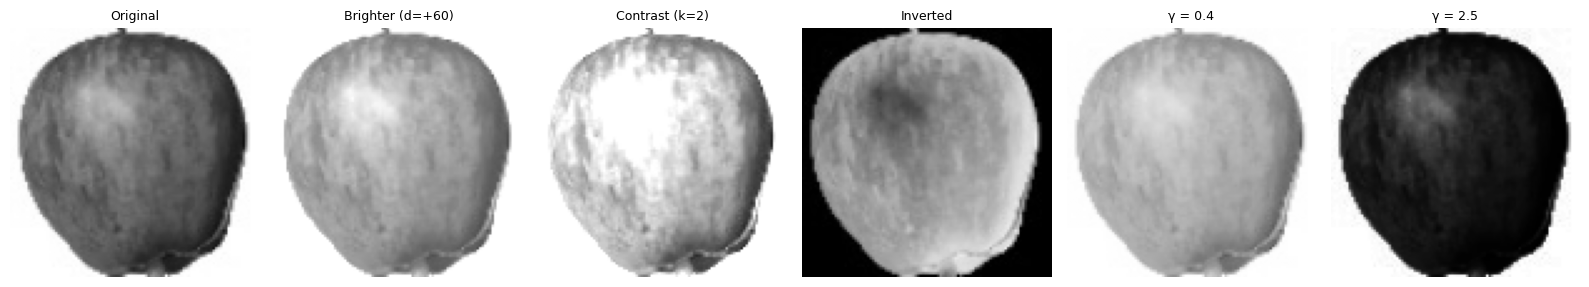

In [3]:
img = load_fruit("Apple Red 1")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def apply_gamma(image, gamma):
    lut = np.array([(i / 255.0) ** gamma * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(image, lut)

ops = [
    ("Original", gray),
    ("Brighter (d=+60)", cv2.convertScaleAbs(gray, alpha=1.0, beta=60)),
    ("Contrast (k=2)", cv2.convertScaleAbs(gray, alpha=2.0, beta=0)),
    ("Inverted", cv2.bitwise_not(gray)),
    ("γ = 0.4", apply_gamma(gray, 0.4)),
    ("γ = 2.5", apply_gamma(gray, 2.5)),
]

fig, axes = plt.subplots(1, len(ops), figsize=(16, 3))
for ax, (title, im) in zip(axes, ops):
    ax.imshow(im, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Color Spaces

Different color spaces encode color in different ways — each useful for different tasks.

### 2.1 RGB Channels

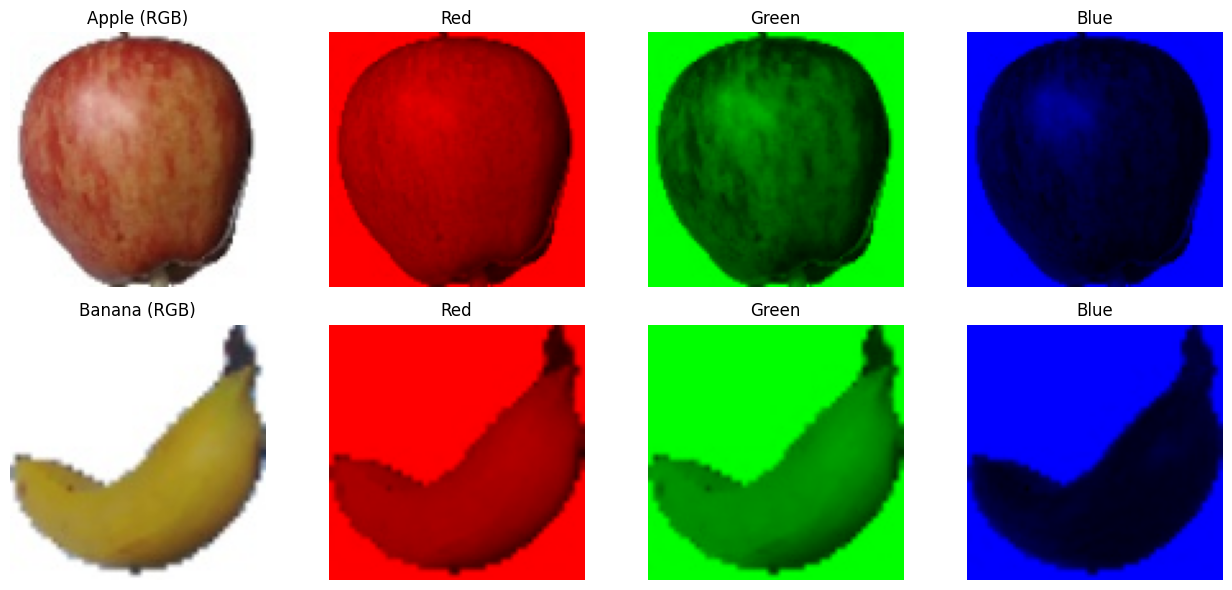

In [4]:
img_apple = load_fruit("Apple Red 1")
img_banana = load_fruit("Banana 1")

def show_rgb_channels(img_bgr, fruit_name, axes_row):
    b, g, r = cv2.split(img_bgr)
    axes_row[0].imshow(to_rgb(img_bgr))
    axes_row[0].set_title(f"{fruit_name} (RGB)")
    for ax, ch, idx, name in zip(axes_row[1:], [r, g, b], [0,1,2], ["Red","Green","Blue"]):
        tinted = np.zeros((*ch.shape, 3), dtype=np.uint8)
        tinted[:, :, idx] = ch
        ax.imshow(tinted)
        ax.set_title(name)
    for ax in axes_row:
        ax.axis("off")

fig, axes = plt.subplots(2, 4, figsize=(13, 6))
show_rgb_channels(img_apple, "Apple", axes[0])
show_rgb_channels(img_banana, "Banana", axes[1])
plt.tight_layout()
plt.show()

### 2.2 HSV — Hue, Saturation, Value

- **Hue** (0–179 in OpenCV): the color type
- **Saturation** (0–255): color purity
- **Value** (0–255): brightness

HSV separates *what color* from *how bright*, making it ideal for **color-based segmentation**.

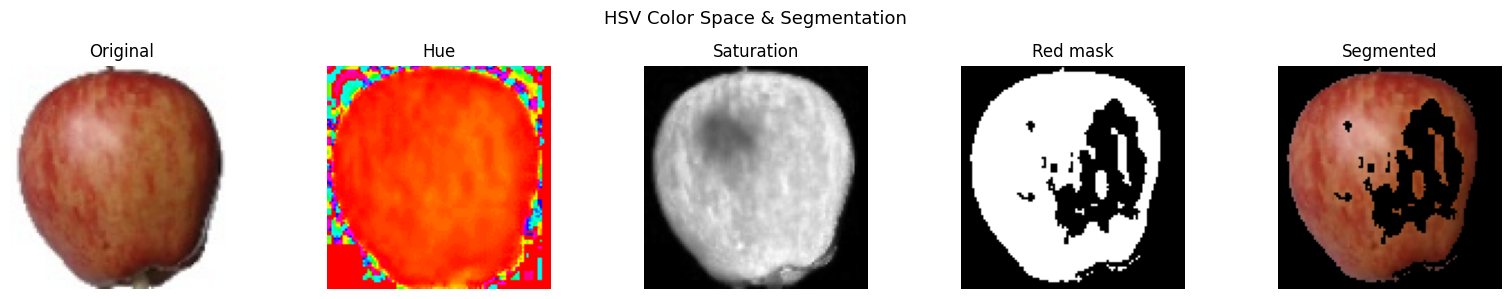

In [5]:
hsv = cv2.cvtColor(img_apple, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# Red hue wraps around 0/180 → two ranges
mask_red = cv2.inRange(hsv, np.array([0,80,80]), np.array([10,255,255])) | \
           cv2.inRange(hsv, np.array([160,80,80]), np.array([179,255,255]))
segmented = cv2.bitwise_and(img_apple, img_apple, mask=mask_red)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(to_rgb(img_apple)); axes[0].set_title("Original")
axes[1].imshow(h, cmap="hsv", vmin=0, vmax=179); axes[1].set_title("Hue")
axes[2].imshow(s, cmap="gray"); axes[2].set_title("Saturation")
axes[3].imshow(mask_red, cmap="gray"); axes[3].set_title("Red mask")
axes[4].imshow(to_rgb(segmented)); axes[4].set_title("Segmented")
for ax in axes: ax.axis("off")
plt.suptitle("HSV Color Space & Segmentation", fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Lab* (CIELAB)

- **L***: Lightness
- **a***: Green ↔ Red
- **b***: Blue ↔ Yellow

Lab* is **perceptually uniform**: equal numerical differences ≈ equal perceived color differences.

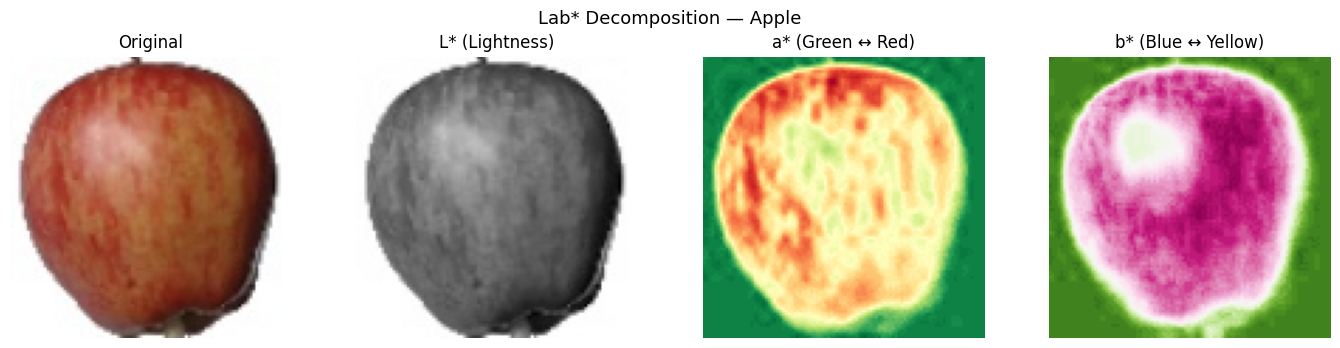

In [6]:
lab = cv2.cvtColor(img_apple, cv2.COLOR_BGR2LAB)
l_ch, a_ch, b_ch = cv2.split(lab)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(to_rgb(img_apple)); axes[0].set_title("Original")
axes[1].imshow(l_ch, cmap="gray"); axes[1].set_title("L* (Lightness)")
axes[2].imshow(a_ch, cmap="RdYlGn_r"); axes[2].set_title("a* (Green ↔ Red)")
axes[3].imshow(b_ch, cmap="PiYG_r"); axes[3].set_title("b* (Blue ↔ Yellow)")
for ax in axes: ax.axis("off")
plt.suptitle("Lab* Decomposition — Apple", fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Color Distributions — Which Space Separates Fruits Best?

Plotting pixel colors of different fruits in 2D color-space planes shows how well each space separates them. This motivates the clustering exercise later.

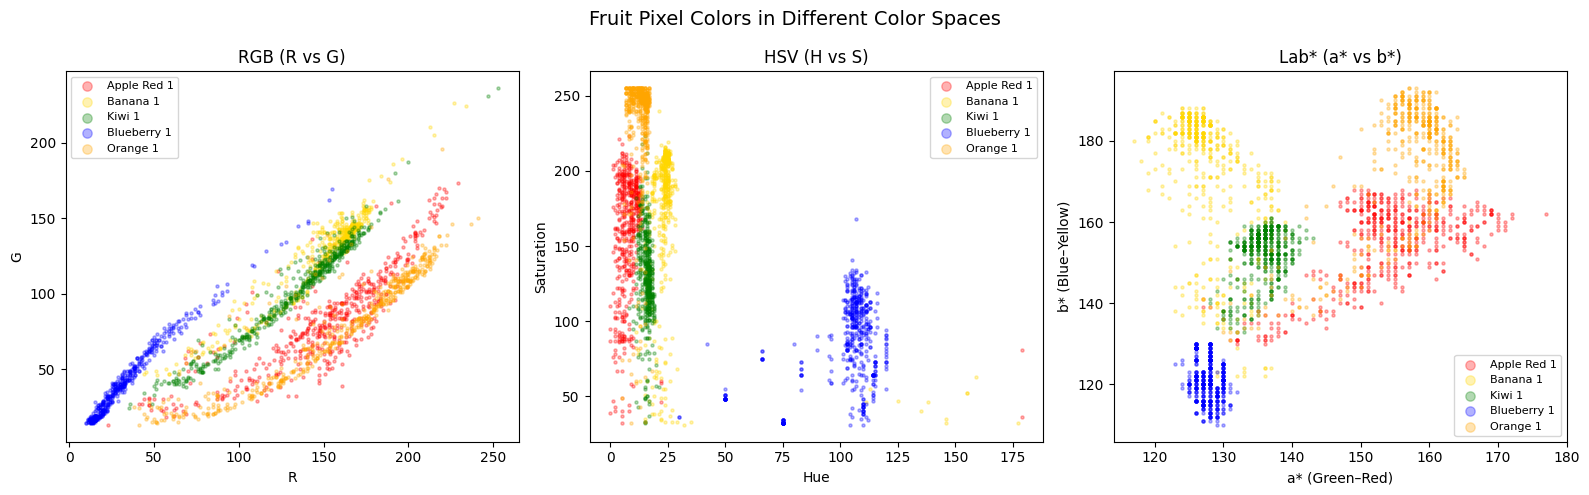

In [7]:
scatter_fruits = {
    "Apple Red 1": "red", "Banana 1": "gold", "Kiwi 1": "green",
    "Blueberry 1": "blue", "Orange 1": "orange",
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for cls_name, color in scatter_fruits.items():
    im = load_fruit(cls_name)
    hsv_im = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
    lab_im = cv2.cvtColor(im, cv2.COLOR_BGR2LAB)
    rgb_im = to_rgb(im)

    mask = hsv_im[:, :, 1] > 30  # exclude white background
    idx = np.random.choice(mask.sum(), min(500, mask.sum()), replace=False)

    axes[0].scatter(rgb_im[mask][idx, 0], rgb_im[mask][idx, 1],
                    c=color, alpha=0.3, s=5, label=cls_name)
    axes[1].scatter(hsv_im[mask][idx, 0], hsv_im[mask][idx, 1],
                    c=color, alpha=0.3, s=5, label=cls_name)
    axes[2].scatter(lab_im[mask][idx, 1], lab_im[mask][idx, 2],
                    c=color, alpha=0.3, s=5, label=cls_name)

axes[0].set(xlabel="R", ylabel="G", title="RGB (R vs G)")
axes[1].set(xlabel="Hue", ylabel="Saturation", title="HSV (H vs S)")
axes[2].set(xlabel="a* (Green–Red)", ylabel="b* (Blue–Yellow)", title="Lab* (a* vs b*)")
for ax in axes: ax.legend(fontsize=8, markerscale=3)
plt.suptitle("Fruit Pixel Colors in Different Color Spaces", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Histograms

A histogram shows the **distribution** of pixel intensities. For 8-bit images: 256 bins where $h_i$ = number of pixels with value $i$.

- Dark image → histogram shifted left | Bright → shifted right
- Low contrast → narrow | High contrast → wide
- **What is lost?** Pixel position — different images can share the same histogram.

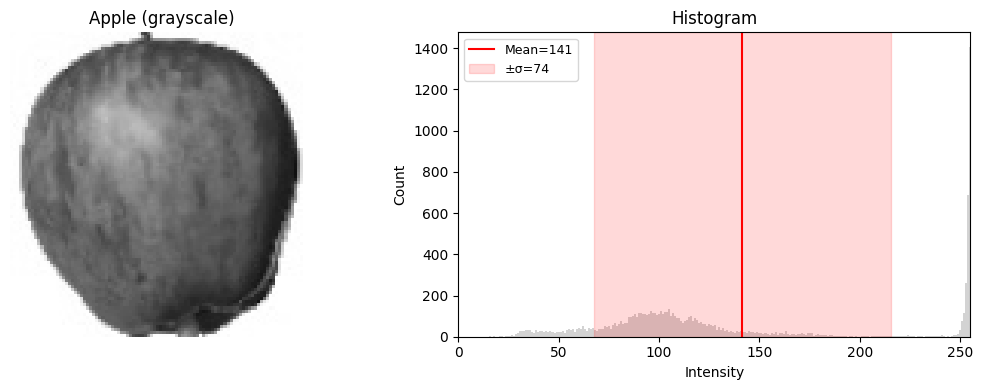

In [8]:
gray_apple = cv2.cvtColor(img_apple, cv2.COLOR_BGR2GRAY)
hist = cv2.calcHist([gray_apple], [0], None, [256], [0, 256]).flatten()
mean_val, std_val = gray_apple.mean(), gray_apple.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(gray_apple, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Apple (grayscale)"); axes[0].axis("off")

axes[1].bar(range(256), hist, width=1, color="lightgray", edgecolor="none")
axes[1].axvline(mean_val, color="red", lw=1.5, label=f"Mean={mean_val:.0f}")
axes[1].axvspan(mean_val-std_val, mean_val+std_val, alpha=0.15, color="red", label=f"±σ={std_val:.0f}")
axes[1].set(xlim=(0,255), xlabel="Intensity", ylabel="Count", title="Histogram")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3.1 How Point Operations Change Histograms

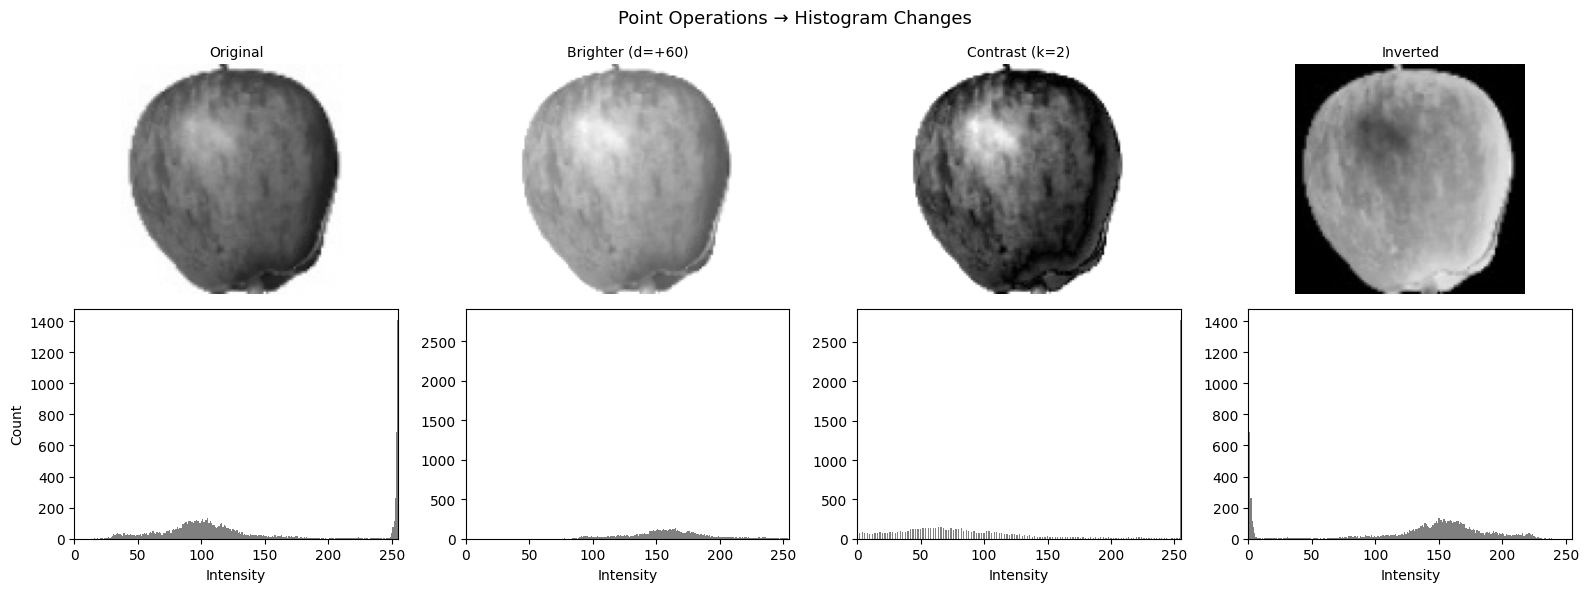

In [9]:
ops = [
    ("Original", gray_apple),
    ("Brighter (d=+60)", cv2.convertScaleAbs(gray_apple, alpha=1.0, beta=60)),
    ("Contrast (k=2)", cv2.convertScaleAbs(gray_apple, alpha=2.0, beta=-128)),
    ("Inverted", cv2.bitwise_not(gray_apple)),
]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for col, (title, im) in enumerate(ops):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title, fontsize=10); axes[0, col].axis("off")
    h = cv2.calcHist([im], [0], None, [256], [0, 256]).flatten()
    axes[1, col].bar(range(256), h, width=1, color="gray", edgecolor="none")
    axes[1, col].set_xlim(0, 255); axes[1, col].set_xlabel("Intensity")
axes[1, 0].set_ylabel("Count")
plt.suptitle("Point Operations → Histogram Changes", fontsize=13)
plt.tight_layout()
plt.show()

### 3.2 Automatic Contrast & Histogram Equalization

**Percentile stretching** maps the 1st–99th percentile range to [0, 255].

**Histogram equalization** uses the cumulative histogram $H(i)$ to make the distribution approximately uniform:
$f_{eq}(a) = H(a) \cdot \frac{255}{M \cdot N}$

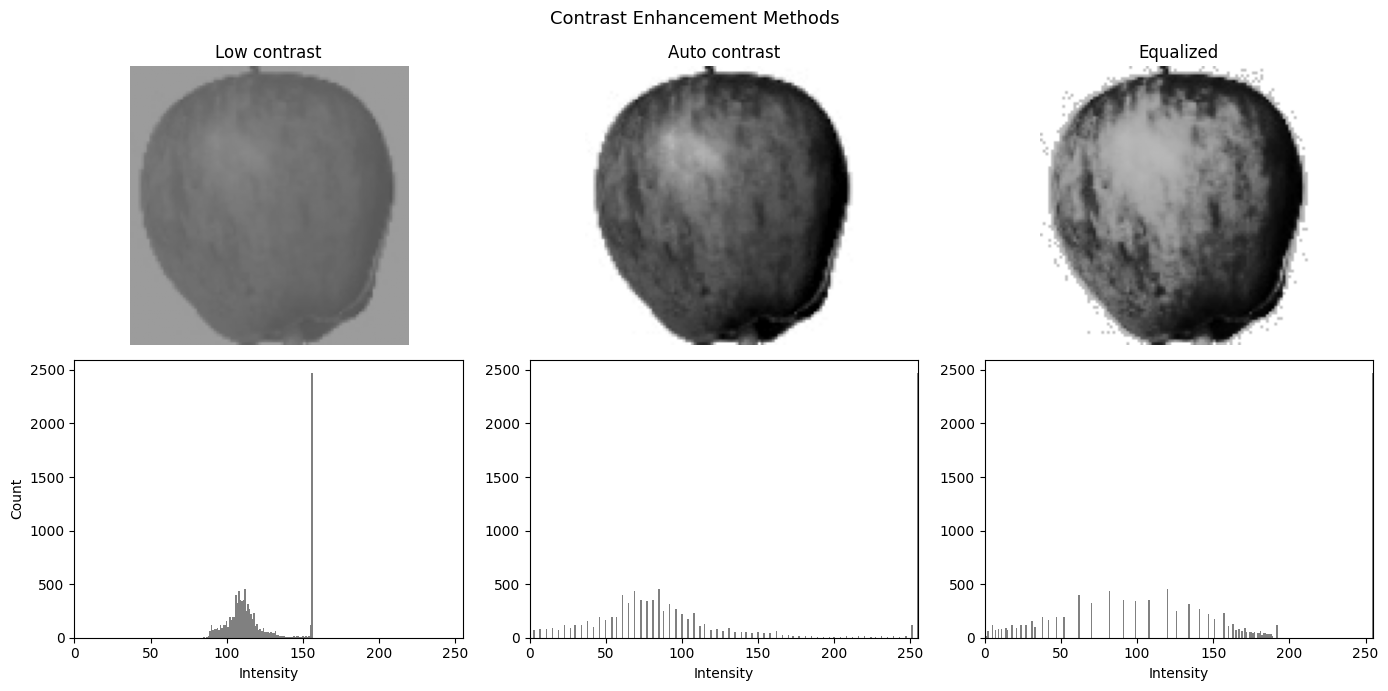

In [10]:
low_contrast = cv2.convertScaleAbs(gray_apple, alpha=0.3, beta=80)

def auto_contrast(image, lo=1, hi=99):
    a_lo, a_hi = np.percentile(image, lo), np.percentile(image, hi)
    return np.clip((image.astype(np.float32) - a_lo) / (a_hi - a_lo) * 255, 0, 255).astype(np.uint8)

stretched = auto_contrast(low_contrast)
equalized = cv2.equalizeHist(low_contrast)

versions = [("Low contrast", low_contrast), ("Auto contrast", stretched),
            ("Equalized", equalized)]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for col, (title, im) in enumerate(versions):
    axes[0, col].imshow(im, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(title); axes[0, col].axis("off")
    h = cv2.calcHist([im], [0], None, [256], [0, 256]).flatten()
    axes[1, col].bar(range(256), h, width=1, color="gray", edgecolor="none")
    axes[1, col].set(xlim=(0,255), xlabel="Intensity")
axes[1, 0].set_ylabel("Count")
plt.suptitle("Contrast Enhancement Methods", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Color Histograms & Fruit Comparison

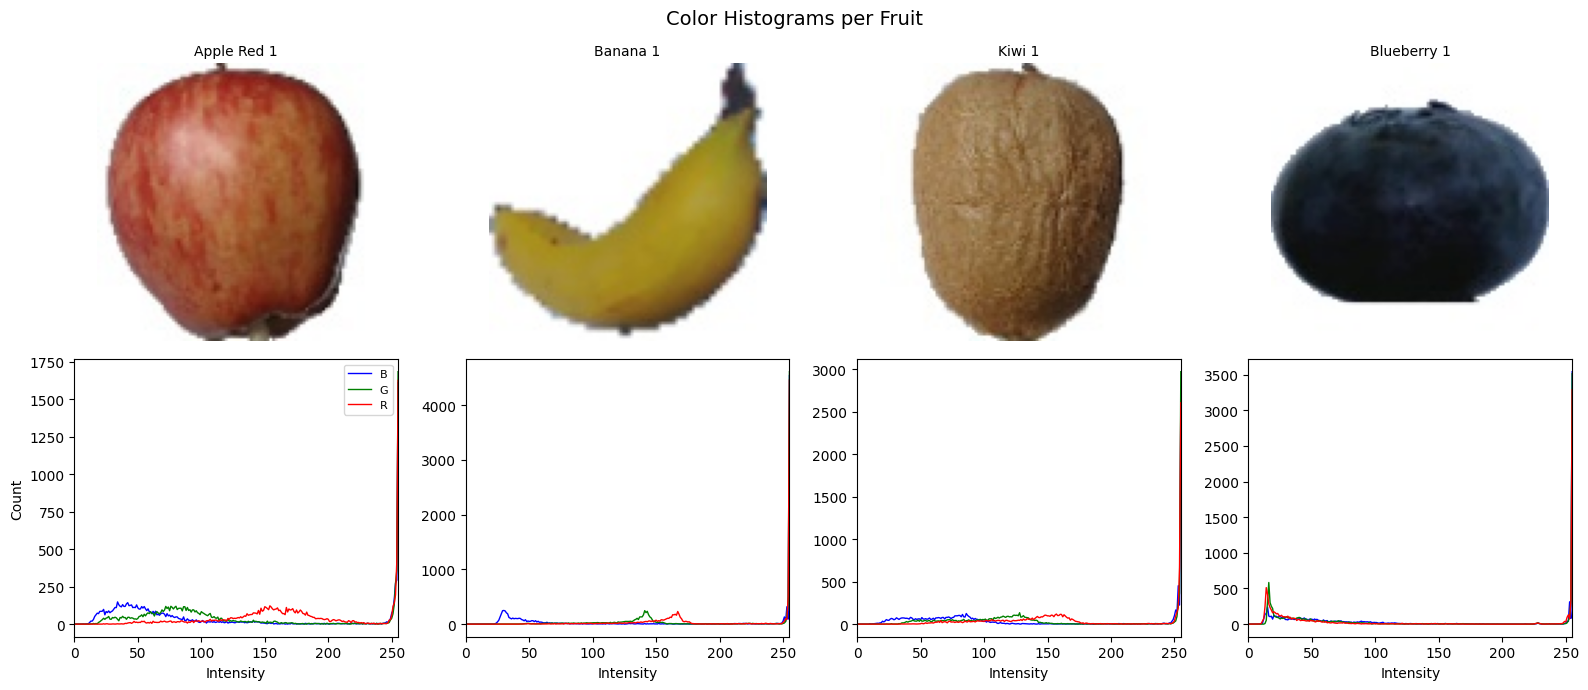

In [11]:
compare_fruits = ["Apple Red 1", "Banana 1", "Kiwi 1", "Blueberry 1"]

fig, axes = plt.subplots(2, len(compare_fruits), figsize=(16, 7))
for col, cls_name in enumerate(compare_fruits):
    im = load_fruit(cls_name)
    axes[0, col].imshow(to_rgb(im))
    axes[0, col].set_title(cls_name, fontsize=10); axes[0, col].axis("off")
    for i, (cname, cplot) in enumerate(zip(["B","G","R"], ["blue","green","red"])):
        h = cv2.calcHist([im], [i], None, [256], [0, 256]).flatten()
        axes[1, col].plot(h, color=cplot, lw=1, label=cname)
    axes[1, col].set(xlim=(0,255), xlabel="Intensity")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(fontsize=8)
plt.suptitle("Color Histograms per Fruit", fontsize=14)
plt.tight_layout()
plt.show()

### 3.4 Comparing Histograms — Measuring Similarity

OpenCV's `cv2.compareHist()` can quantify how similar two histograms are. This lets us compare fruits numerically.

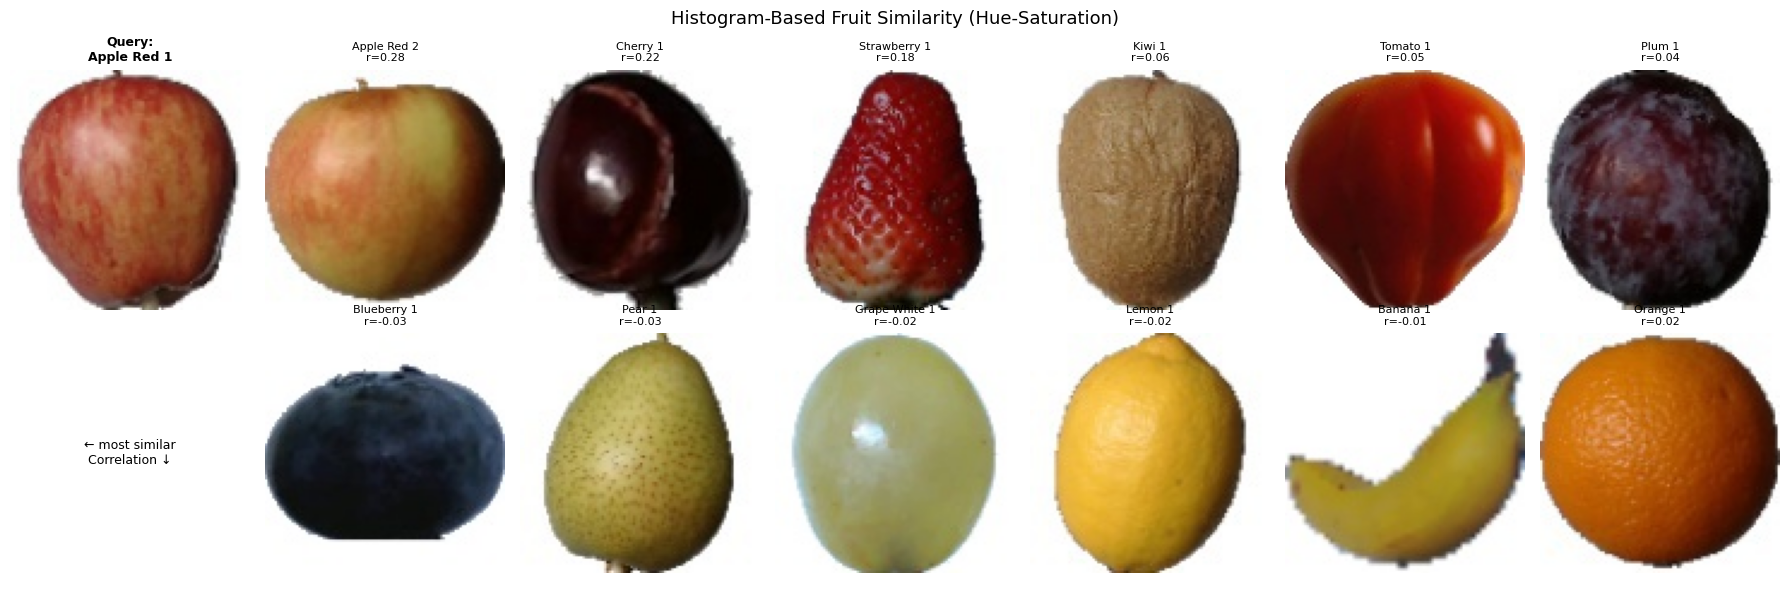

In [12]:
def fruit_hs_hist(class_name, index=0):
    """Compute a normalized 2D Hue-Saturation histogram for a fruit image."""
    im = load_fruit(class_name, index)
    hsv_im = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
    mask = (hsv_im[:, :, 1] > 30).astype(np.uint8) * 255
    hist = cv2.calcHist([hsv_im], [0, 1], mask, [30, 32], [0, 180, 0, 256])
    cv2.normalize(hist, hist)
    return hist

query = "Apple Red 1"
query_hist = fruit_hs_hist(query)

candidates = ["Apple Red 2", "Cherry 1", "Strawberry 1", "Tomato 1",
              "Banana 1", "Lemon 1", "Orange 1", "Kiwi 1",
              "Blueberry 1", "Pear 1", "Grape White 1", "Plum 1"]

scores = []
for c in candidates:
    h = fruit_hs_hist(c)
    corr = cv2.compareHist(query_hist, h, cv2.HISTCMP_CORREL)
    bhat = cv2.compareHist(query_hist, h, cv2.HISTCMP_BHATTACHARYYA)
    scores.append((c, corr, bhat))

scores.sort(key=lambda x: x[1], reverse=True)  # sort by correlation (higher = more similar)

fig, axes = plt.subplots(2, 7, figsize=(18, 6))
axes[0, 0].imshow(to_rgb(load_fruit(query)))
axes[0, 0].set_title(f"Query:\n{query}", fontsize=9, fontweight="bold")
axes[0, 0].axis("off")
axes[1, 0].axis("off")
axes[1, 0].text(0.5, 0.5, "← most similar\nCorrelation ↓", ha="center", va="center", fontsize=9)

for i, (name, corr, bhat) in enumerate(scores[:6]):
    axes[0, i+1].imshow(to_rgb(load_fruit(name)))
    axes[0, i+1].set_title(f"{name}\nr={corr:.2f}", fontsize=8)
    axes[0, i+1].axis("off")

scores_worst = sorted(scores, key=lambda x: x[1])  # least similar first
for i, (name, corr, bhat) in enumerate(scores_worst[:6]):
    axes[1, i+1].imshow(to_rgb(load_fruit(name)))
    axes[1, i+1].set_title(f"{name}\nr={corr:.2f}", fontsize=8)
    axes[1, i+1].axis("off")

axes[0, 1].set_ylabel("Most similar", fontsize=10)
axes[1, 1].set_ylabel("Least similar", fontsize=10)
plt.suptitle("Histogram-Based Fruit Similarity (Hue-Saturation)", fontsize=13)
plt.tight_layout()
plt.show()

## ✏️ Exercises

### Exercise 1: Color-Based Fruit Classification with Clustering

Can we distinguish fruit types purely by their color? Use color features and K-Means clustering to find out.

**Steps:**

1. **Select 5 fruit classes** that you expect to be distinguishable by color (e.g., Apple Red, Banana, Kiwi, Blueberry, Orange)
2. **Load 20–30 images per class** from the training set
3. **Extract color features** for each image:
   - Compute the **mean color** of the fruit pixels (exclude the white background using an HSV saturation mask: `hsv[:,:,1] > 30`)
   - Try at least **two different color spaces** — e.g., mean HSV and mean Lab* values
4. **Visualize** the per-image features as 2D scatter plots (e.g., mean a* vs. mean b*, or mean Hue vs. mean Saturation), colored by true fruit class
5. **Cluster** the feature vectors with **K-Means** (`sklearn.cluster.KMeans`, $k$ = number of classes)
6. **Evaluate and compare:**
   - Show two scatter plots side by side: one colored by **true class**, one by **cluster assignment**
   - Use `sklearn.metrics.adjusted_rand_score` to quantify cluster quality
   - Which color space produces the best separation? Why?
7. **Stretch goal:** Try adding more fruit classes (e.g., 10) — at what point does pure color fail to separate them? Which classes get confused?

**Hints:**
```python
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Load multiple images per class
for i in range(30):
    img = load_fruit(class_name, index=i)

# Background mask
hsv_im = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
mask = hsv_im[:, :, 1] > 30
fruit_pixels = lab_im[mask]  # only fruit pixels
mean_color = fruit_pixels.mean(axis=0)

# Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")  # 1.0 = perfect, 0.0 = random
```

In [ ]:
# Your code here
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

class_name = scatter_fruits

# Load multiple images per class
for i in range(30):
    img = load_fruit(class_name, index=i)

# Background mask
hsv_im = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
mask = hsv_im[:, :, 1] > 30
fruit_pixels = lab_im[mask]  # only fruit pixels
mean_color = fruit_pixels.mean(axis=0)

# Clustering
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(features)
ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"Adjusted Rand Index: {ari:.3f}")

### Exercise 2 *(optional — for fast finishers)*: Histogram-Based Fruit Retrieval

Build a simple **image retrieval** system: given a query fruit, find the most (and least) similar fruits using histogram comparison.

**Tasks:**
1. Pick a **query image** from any fruit class
2. Compute a **2D hue-saturation histogram** (see `fruit_hs_hist` above) for the query and for one sample image from each of **at least 20 different fruit classes**
3. Rank all candidates using `cv2.compareHist()` with:
   - `cv2.HISTCMP_CORREL` (higher = more similar)
   - `cv2.HISTCMP_BHATTACHARYYA` (lower = more similar)
4. Display the query alongside the **top-5 most similar** and **bottom-5 least similar** fruits
5. Try a **second query** from a very different fruit — do the rankings make sense?
6. **Discuss:** Do the two comparison metrics agree? When do they disagree, and why?

In [14]:
# Your code here
